In [1]:
from IPython.display import Markdown, display

display(Markdown("""
**Ноутбук 4: 04_Neural_Network_MLP.ipynb**

Четвёртый ноутбук посвящён разработке и улучшению многослойного персептрона. Базовая архитектура: 128, 64, 32 нейрона с ReLU, BatchNormalization и Dropout (0.3, 0.3, 0.2), выходной слой – сигмоида. Модель обучалась с ранней остановкой по val_auc. 

Базовая MLP показала ROC‑AUC 0,7428, но из-за дисбаланса предсказывала лишь 0,1% положительных объектов. Применение class_weight кардинально улучшило ситуацию: F1 вырос до 0,251. Дополнительный подбор порога по максимуму F1 на валидации (0,6474) дал F1 = 0,2927. L2‑регуляризация и SMOTE (sampling_strategy=0,3) не дали преимущества. Лучшая модификация (class_weight + порог) сохранена как mlp_model_best.keras. Несмотря на улучшенный F1, ROC‑AUC (0,7433) остался ниже, чем у LightGBM (0,7519), поэтому основной моделью оставлен бустинг, а MLP – альтернативой.
"""))


**Ноутбук 4: 04_Neural_Network_MLP.ipynb**

Четвёртый ноутбук посвящён разработке и улучшению многослойного персептрона. Базовая архитектура: 128, 64, 32 нейрона с ReLU, BatchNormalization и Dropout (0.3, 0.3, 0.2), выходной слой – сигмоида. Модель обучалась с ранней остановкой по val_auc. 

Базовая MLP показала ROC‑AUC 0,7428, но из-за дисбаланса предсказывала лишь 0,1% положительных объектов. Применение class_weight кардинально улучшило ситуацию: F1 вырос до 0,251. Дополнительный подбор порога по максимуму F1 на валидации (0,6474) дал F1 = 0,2927. L2‑регуляризация и SMOTE (sampling_strategy=0,3) не дали преимущества. Лучшая модификация (class_weight + порог) сохранена как mlp_model_best.keras. Несмотря на улучшенный F1, ROC‑AUC (0,7433) остался ниже, чем у LightGBM (0,7519), поэтому основной моделью оставлен бустинг, а MLP – альтернативой.


Импорт

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score, brier_score_loss, precision_recall_fscore_support, classification_report, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Загрузка данных

In [2]:
preprocessor = joblib.load('../artifacts/preprocessor.pkl')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train_lin.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val_lin.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test_lin.csv').values.ravel()

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train shape: {X_train_processed.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val_processed.shape}, y_val shape: {y_val.shape}")

X_train shape: (215257, 168), y_train shape: (215257,)
X_val shape: (46127, 168), y_val shape: (46127,)


Построение модели MLP: модель с двумя скрытыми слоями с Dropout и BatchNormalization.

In [3]:
input_dim = X_train_processed.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')  # бинарная классификация
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          21,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,449 (126.75 KB)

 Non-trainable params: 448 (1.75 KB)

Обучение с ранней остановкой

In [4]:
early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8778 - auc: 0.6104 - loss: 0.3451 - val_accuracy: 0.9193 - val_auc: 0.7314 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 2/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9185 - auc: 0.7119 - loss: 0.2618 - val_accuracy: 0.9193 - val_auc: 0.7379 - val_loss: 0.2524 - learning_rate: 0.0010
Epoch 3/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9187 - auc: 0.7238 - loss: 0.2575 - val_accuracy: 0.9193 - val_auc: 0.7407 - val_loss: 0.2516 - learning_rate: 0.0010
Epoch 4/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9190 - auc: 0.7298 - loss: 0.2552 - val_accuracy: 0.9193 - val_auc: 0.7405 - val_loss: 0.2515 - learning_rate: 0.0010
Epoch 5/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9190 - auc: 0.7340 - loss: 0.2539 - val_accuracy: 0.9193 - val_auc: 0.7427 - val_loss: 0.2510 - learning_rate: 0.0010
Epoch 6/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9191 - a

Визуализация обучения

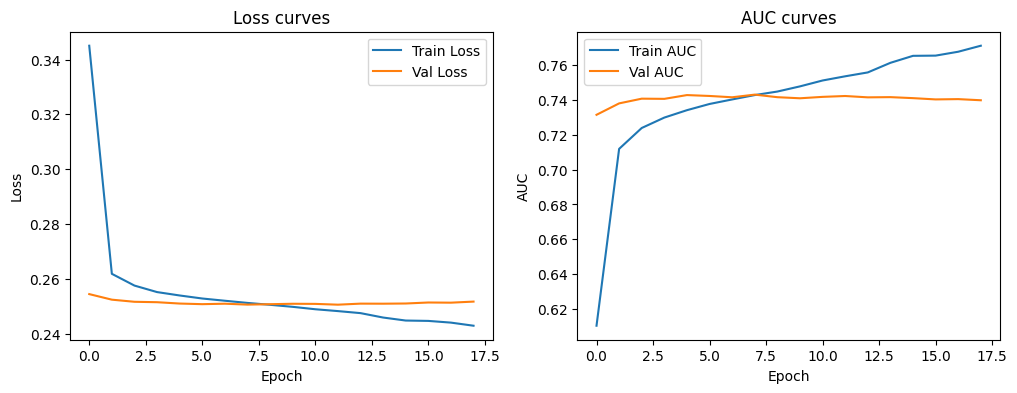

In [5]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.title('AUC curves')
plt.show()

Оценка на валидации

In [6]:
y_val_proba_mlp = model.predict(X_val_processed).ravel()
y_val_pred_mlp = (y_val_proba_mlp >= 0.5).astype(int)

roc_auc_mlp = roc_auc_score(y_val, y_val_proba_mlp)
brier_mlp = brier_score_loss(y_val, y_val_proba_mlp)
precision_mlp, recall_mlp, f1_mlp, _ = precision_recall_fscore_support(y_val, y_val_pred_mlp, average='binary')

print("MLP на валидационной выборке")
print(f"ROC-AUC: {roc_auc_mlp:.4f}")
print(f"Brier score: {brier_mlp:.4f}")
print(f"Precision: {precision_mlp:.4f}, Recall: {recall_mlp:.4f}, F1: {f1_mlp:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_mlp, target_names=['No Default', 'Default']))

1442/1442 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step
MLP на валидационной выборке
ROC-AUC: 0.7428
Brier score: 0.0688
Precision: 0.8000, Recall: 0.0011, F1: 0.0021

Classification Report:
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     42403
     Default       0.80      0.00      0.00      3724

    accuracy                           0.92     46127
   macro avg       0.86      0.50      0.48     46127
weighted avg       0.91      0.92      0.88     46127



Сравнение с LightGBM

In [7]:
best_lgb = joblib.load('../artifacts/best_model.pkl')
y_val_proba_lgb = best_lgb.predict_proba(X_val_processed)[:, 1]
y_val_pred_lgb = (y_val_proba_lgb >= 0.5).astype(int)

roc_auc_lgb = roc_auc_score(y_val, y_val_proba_lgb)
brier_lgb = brier_score_loss(y_val, y_val_proba_lgb)
precision_lgb, recall_lgb, f1_lgb, _ = precision_recall_fscore_support(y_val, y_val_pred_lgb, average='binary')

print("LightGBM на валидации")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(f"Brier: {brier_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}, Recall: {recall_lgb:.4f}, F1: {f1_lgb:.4f}")

comparison = pd.DataFrame({
    'Model': ['LightGBM', 'MLP'],
    'ROC-AUC': [roc_auc_lgb, roc_auc_mlp],
    'Brier': [brier_lgb, brier_mlp],
    'Precision': [precision_lgb, precision_mlp],
    'Recall': [recall_lgb, recall_mlp],
    'F1': [f1_lgb, f1_mlp]
})
print("\nСравнение моделей:")
print(comparison.round(4))

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM на валидации
ROC-AUC: 0.7519
Brier: 0.1943
Precision: 0.1622, Recall: 0.6702, F1: 0.2613

Сравнение моделей:
      Model  ROC-AUC   Brier  Precision  Recall      F1
0  LightGBM   0.7519  0.1943     0.1622  0.6702  0.2613
1       MLP   0.7428  0.0688     0.8000  0.0011  0.0021


ROC-кривые сравнения

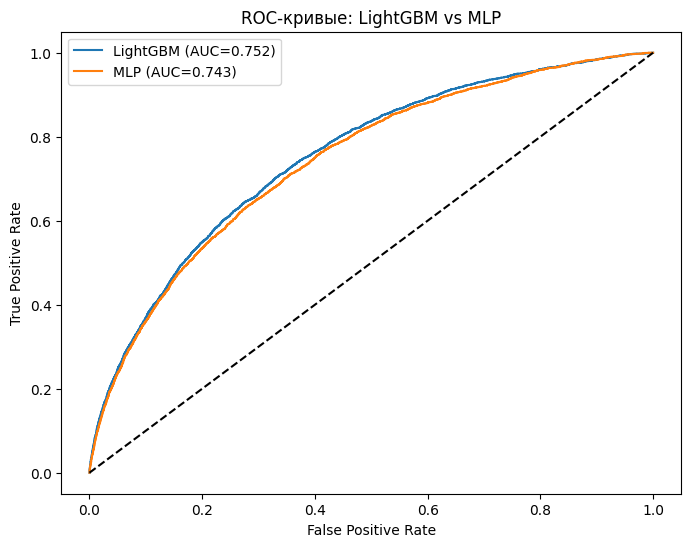

In [8]:
plt.figure(figsize=(8, 6))
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_val_proba_lgb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_val, y_val_proba_mlp)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={roc_auc_lgb:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC={roc_auc_mlp:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: LightGBM vs MLP')
plt.legend()
plt.show()

Сохранение модели MLP

In [9]:
model.save('../artifacts/mlp_model.keras')
print("MLP модель сохранена в '../artifacts/mlp_model.keras'")

MLP модель сохранена в '../artifacts/mlp_model.keras'


In [23]:
from IPython.display import Markdown, display

display(Markdown("""
## Базовая MLP и сравнение с LightGBM

В рамках первого этапа была обучена многослойная нейронная сеть архитектуры 128–64–32 с BatchNormalization, Dropout (0.3, 0.3, 0.2) и сигмоидным выходом. Модель обучалась на 215257 образцах и валидировалась на 46127 образцах. На валидационной выборке базовая MLP достигла ROC‑AUC = 0.7428 и Brier score = 0.0688. Однако из-за сильного дисбаланса классов (доля дефолтов 8.6%) при стандартном пороге 0.5 модель предсказала лишь 0.1% положительных объектов, что привело к recall = 0.0011 и F1 = 0.0021. Сравнение с ранее обученным LightGBM показало, что бустинг значительно эффективнее: LightGBM имеет ROC‑AUC = 0.7519, recall = 0.6702, F1 = 0.2613. Базовая MLP без учёта дисбаланса непригодна для практического использования и требует модификации для повышения чувствительности к дефолтам.
"""))


## Базовая MLP и сравнение с LightGBM

В рамках первого этапа была обучена многослойная нейронная сеть архитектуры 128–64–32 с BatchNormalization, Dropout (0.3, 0.3, 0.2) и сигмоидным выходом. Модель обучалась на 215257 образцах и валидировалась на 46127 образцах. На валидационной выборке базовая MLP достигла ROC‑AUC = 0.7428 и Brier score = 0.0688. Однако из-за сильного дисбаланса классов (доля дефолтов 8.6%) при стандартном пороге 0.5 модель предсказала лишь 0.1% положительных объектов, что привело к recall = 0.0011 и F1 = 0.0021. Сравнение с ранее обученным LightGBM показало, что бустинг значительно эффективнее: LightGBM имеет ROC‑AUC = 0.7519, recall = 0.6702, F1 = 0.2613. Базовая MLP без учёта дисбаланса непригодна для практического использования и требует модификации для повышения чувствительности к дефолтам.


Эксперименты

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve, f1_score
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import backend as K

Функция создания MLP (параметризуем)

In [12]:
def create_mlp(input_dim, dropout_rates=(0.3, 0.3, 0.2), l2_reg=0.0):
    from tensorflow.keras.regularizers import l2
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(l2_reg) if l2_reg else None),
        BatchNormalization(),
        Dropout(dropout_rates[0]),
        Dense(64, activation='relu', kernel_regularizer=l2(l2_reg) if l2_reg else None),
        BatchNormalization(),
        Dropout(dropout_rates[1]),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg) if l2_reg else None),
        BatchNormalization(),
        Dropout(dropout_rates[2]),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

Эксперимент 1 – class_weight

In [13]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

model_cw = create_mlp(input_dim)
early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_cw = model_cw.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100, batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_val_proba_cw = model_cw.predict(X_val_processed).ravel()
y_val_pred_cw = (y_val_proba_cw >= 0.5).astype(int)
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_cw):.4f}")
print(f"F1: {f1_score(y_val, y_val_pred_cw):.4f}")
print(classification_report(y_val, y_val_pred_cw))

Class weights: {0: np.float64(0.54390792399434), 1: np.float64(6.193733095471025)}


C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6173 - auc: 0.6851 - loss: 0.6555 - val_accuracy: 0.6302 - val_auc: 0.7371 - val_loss: 0.6509 - learning_rate: 0.0010
Epoch 2/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6603 - auc: 0.7283 - loss: 0.6113 - val_accuracy: 0.6619 - val_auc: 0.7403 - val_loss: 0.6176 - learning_rate: 0.0010
Epoch 3/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6668 - auc: 0.7354 - loss: 0.6047 - val_accuracy: 0.6671 - val_auc: 0.7409 - val_loss: 0.6105 - learning_rate: 0.0010
Epoch 4/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6695 - auc: 0.7392 - loss: 0.6014 - val_accuracy: 0.6674 - val_auc: 0.7418 - val_loss: 0.6021 - learning_rate: 0.0010
Epoch 5/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6713 - auc: 0.7412 - loss: 0.5995 - val_accuracy: 0.6638 - val_auc: 0.7428 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 6/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6710

Эксперимент 2 – подбор порога

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_cw)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.4f}")

y_val_pred_tuned = (y_val_proba_cw >= best_threshold).astype(int)
print(f"F1 после tuning порога: {f1_score(y_val, y_val_pred_tuned):.4f}")
print(classification_report(y_val, y_val_pred_tuned))

Best threshold: 0.6474
F1 после tuning порога: 0.2927
              precision    recall  f1-score   support

           0       0.95      0.86      0.90     42403
           1       0.22      0.45      0.29      3724

    accuracy                           0.82     46127
   macro avg       0.58      0.65      0.60     46127
weighted avg       0.89      0.82      0.85     46127



Эксперимент 3 – архитектура с L2-регуляризацией

In [15]:
model_l2 = create_mlp(input_dim, l2_reg=0.001)
history_l2 = model_l2.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100, batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
y_val_proba_l2 = model_l2.predict(X_val_processed).ravel()
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_l2):.4f}")

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6293 - auc: 0.6841 - loss: 0.8459 - val_accuracy: 0.6437 - val_auc: 0.7348 - val_loss: 0.7628 - learning_rate: 0.0010
Epoch 2/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6626 - auc: 0.7269 - loss: 0.7177 - val_accuracy: 0.6612 - val_auc: 0.7393 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 3/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6685 - auc: 0.7330 - loss: 0.6630 - val_accuracy: 0.6661 - val_auc: 0.7397 - val_loss: 0.6501 - learning_rate: 0.0010
Epoch 4/100
841/841 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6700 - auc: 0.7344 - loss: 0.6361 - val_accuracy: 0.6723 - val_auc: 0.7397 - val_loss: 0.6340 - learning_rate: 0.0010
Epoch 5/100
838/841 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6722 - auc: 0.7362 - loss: 0.6222
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6699 - auc: 0.7360 - loss: 

Эксперимент 4 – SMOTE

In [16]:
smote = SMOTE(random_state=42, sampling_strategy=0.3)  # увеличиваем долю дефолтов до 30%
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
print(f"After SMOTE: {np.bincount(y_train_smote)}")

model_smote = create_mlp(X_train_smote.shape[1])
history_smote = model_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_processed, y_val),
    epochs=100, batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
y_val_proba_smote = model_smote.predict(X_val_processed).ravel()
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_smote):.4f}")

After SMOTE: [197880  59364]


C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7591 - auc: 0.7145 - loss: 0.5064 - val_accuracy: 0.8915 - val_auc: 0.7327 - val_loss: 0.3294 - learning_rate: 0.0010
Epoch 2/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7911 - auc: 0.7740 - loss: 0.4524 - val_accuracy: 0.8936 - val_auc: 0.7285 - val_loss: 0.3177 - learning_rate: 0.0010
Epoch 3/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8044 - auc: 0.8003 - loss: 0.4308 - val_accuracy: 0.8950 - val_auc: 0.7227 - val_loss: 0.3045 - learning_rate: 0.0010
Epoch 4/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8186 - auc: 0.8213 - loss: 0.4106 - val_accuracy: 0.9016 - val_auc: 0.7193 - val_loss: 0.2929 - learning_rate: 0.0010
Epoch 5/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8300 - auc: 0.8359 - loss: 0.3940 - val_accuracy: 0.8991 - val_auc: 0.7204 - val_loss: 0.2901 - learning_rate: 0.0010
Epoch 6/100
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accu

In [17]:
results = pd.DataFrame({
    'Experiment': ['Base MLP', 'Class_weight', 'Class_weight + threshold', 'L2 reg', 'SMOTE'],
    'ROC-AUC': [
        roc_auc_mlp,
        roc_auc_score(y_val, y_val_proba_cw),
        roc_auc_score(y_val, y_val_proba_cw),  # порог не влияет на AUC
        roc_auc_score(y_val, y_val_proba_l2),
        roc_auc_score(y_val, y_val_proba_smote)
    ],
    'F1 (default threshold)': [
        f1_score(y_val, (y_val_proba_mlp >= 0.5).astype(int)),
        f1_score(y_val, (y_val_proba_cw >= 0.5).astype(int)),
        f1_score(y_val, (y_val_proba_cw >= best_threshold).astype(int)),
        f1_score(y_val, (y_val_proba_l2 >= 0.5).astype(int)),
        f1_score(y_val, (y_val_proba_smote >= 0.5).astype(int))
    ]
})
results.round(4)

,Experiment,ROC-AUC,F1 (default threshold)
0,Base MLP,0.7428,0.0021
1,Class_weight,0.7433,0.2513
2,Class_weight + threshold,0.7433,0.2927
3,L2 reg,0.7348,0.2428
4,SMOTE,0.7328,0.2411


In [18]:
model_cw.save('../artifacts/mlp_model_best.keras')
print("Лучшая MLP модель сохранена в '../artifacts/mlp_model_best.keras'")

Лучшая MLP модель сохранена в '../artifacts/mlp_model_best.keras'


In [19]:
import json
with open('../artifacts/best_threshold.json', 'w') as f:
    json.dump({'threshold': float(best_threshold)}, f)
print(f"Оптимальный порог {best_threshold:.4f} сохранён")

Оптимальный порог 0.6474 сохранён


In [20]:
model_info = {
    'selected_model': 'LightGBM',
    'mlp_threshold': float(best_threshold) if 'best_threshold' in dir() else 0.5,
    'models_path': {
        'LightGBM': '../artifacts/best_model.pkl',
        'MLP': '../artifacts/mlp_model_best.keras'
    }
}
import json
with open('../artifacts/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("model_info.json сохранён")

model_info.json сохранён


In [25]:
display(Markdown("""
## Эксперименты по улучшению MLP

Для исправления недостатков базовой MLP были проведены эксперименты с методами борьбы с дисбалансом классов. Применение `class_weight` кардинально улучшило F1 с 0.002 до 0.251, практически не изменив ROC‑AUC (0.7433). Дополнительный подбор оптимального порога по критерию максимальной F1 дал порог 0.6474 и увеличил F1 до 0.2927. Эксперименты с L2-регуляризацией (0.001) и SMOTE (sampling_strategy=0.3) не принесли преимущества: ROC‑AUC снизился до 0.7348 и 0.7328, а F1 — до 0.243 и 0.241 соответственно. Лучшая модификация (class_weight + порог 0.6474) достигла F1 = 0.2927, что выше, чем у LightGBM (0.2613), хотя ROC‑AUC остаётся ниже (0.7433 против 0.7519). По совокупности характеристик для кредитного скоринга оставлен LightGBM как более стабильная модель, но настроенная MLP сохранена как альтернатива (`mlp_model_best.keras`) вместе с оптимальным порогом (`best_threshold.json`).
"""))


## Эксперименты по улучшению MLP

Для исправления недостатков базовой MLP были проведены эксперименты с методами борьбы с дисбалансом классов. Применение `class_weight` кардинально улучшило F1 с 0.002 до 0.251, практически не изменив ROC‑AUC (0.7433). Дополнительный подбор оптимального порога по критерию максимальной F1 дал порог 0.6474 и увеличил F1 до 0.2927. Эксперименты с L2-регуляризацией (0.001) и SMOTE (sampling_strategy=0.3) не принесли преимущества: ROC‑AUC снизился до 0.7348 и 0.7328, а F1 — до 0.243 и 0.241 соответственно. Лучшая модификация (class_weight + порог 0.6474) достигла F1 = 0.2927, что выше, чем у LightGBM (0.2613), хотя ROC‑AUC остаётся ниже (0.7433 против 0.7519). По совокупности характеристик для кредитного скоринга оставлен LightGBM как более стабильная модель, но настроенная MLP сохранена как альтернатива (`mlp_model_best.keras`) вместе с оптимальным порогом (`best_threshold.json`).
